<a href="https://colab.research.google.com/github/oszavla/Dirac-Schwarz/blob/main/Koneksi_Affine_Spinor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Koneksi *Affine* Spinor *Signature* $(-+++)$

In [ ]:
import sympy as sp
from sympy import symbols, simplify, latex, Matrix
from sympy.physics.quantum import Commutator, AntiCommutator
from sympy.physics.quantum import Operator, Dagger

# ------------------------------
# 1. Definisi simbol dan fungsi
# ------------------------------
t, r, theta, phi = symbols('t r theta phi', real=True)
m, c = symbols('m c', positive=True)

f = (1 - 2*m/r)**(1/2)

# ------------------------------
# 2. Konstanta struktur C_abc
# ------------------------------
C = {}  # (a,b,c) -> ekspresi

# Komponen tak-nol
C[(0,0,1)] = -m/(r**2 * f)
C[(0,1,0)] = -C[(0,0,1)]
C[(2,1,2)] = -f/r
C[(2,2,1)] = -C[(2,1,2)]
C[(3,1,3)] = C[(2,1,2)]
C[(3,3,1)] = -C[(3,1,3)]
C[(3,2,3)] = -sp.cot(theta)/(r)
C[(3,3,2)] = -C[(3,2,3)]

# ------------------------------
# 3. Hitung gamma_abc
# ------------------------------
gamma = {}  # (a,b,c) -> ekspresi

for a in range(4):
    for b in range(4):
        for c in range(4):
            C_abc = C.get((a,b,c), 0)
            C_bca = C.get((b,c,a), 0)
            C_cab = C.get((c,a,b), 0)
            val = -sp.Rational(1,2) * (C_abc + C_bca - C_cab)
            val = simplify(val)
            if val != 0:
                gamma[(a,b,c)] = val


for (a,b,c), val in sorted(gamma.items()):
    print(f"\\gamma_{{{a}{b}{c}}} &= {latex(val)}\\\\")

# ------------------------------
# 4. Aljabar matriks Dirac
# ------------------------------
# Definisikan matriks Dirac sebagai simbol non-komutatif
# Menggunakan Operator dari sympy.physics.quantum
class DiracMatrix(Operator):
    pass

# Buat empat matriks γ^0, γ^1, γ^2, γ^3
gamma_up = [DiracMatrix(f'\\gamma^{i}') for i in range(4)]

# Metrik Minkowski eta^{ab} (invers dari eta_ab)
eta_up = Matrix([[-1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]])

# Relasi anti-komutasi: {γ^a, γ^b} = 2 η^{ab} I
# Kita akan menangani penyederhanaan produk dengan aturan pengurutan
# Untuk keperluan ini, kita cukup menyimpan ekspresi simbolik
# tanpa menyederhanakan lebih lanjut karena hanya sampai produk dua matriks.

# ------------------------------
# 5. Hitung Γ_a = 1/8 γ_{cba} [γ^c, γ^b]
# ------------------------------
Gamma = []  # untuk a=0,1,2,3

for a in range(4):
    expr = 0
    for b in range(4):
        for c in range(4):
            gamma_cba = gamma.get((c,b,a), 0)
            if gamma_cba != 0:
                # Komutator [γ^c, γ^b]
                comm = gamma_up[b] * gamma_up[c] - gamma_up[c] * gamma_up[b]
                expr = expr + gamma_cba * comm
    expr = simplify(expr) / 8
    Gamma.append(expr)


for a, gam in enumerate(Gamma):
    print(f"\\Gamma_{a} &= {latex(gam)}\\\\")

\gamma_{010} &= - \frac{m}{r^{2} \left(- \frac{2 m - r}{r}\right)^{0.5}}\\
\gamma_{100} &= \frac{m}{r^{2} \left(\frac{- 2 m + r}{r}\right)^{0.5}}\\
\gamma_{122} &= - \frac{\left(- \frac{2 m - r}{r}\right)^{0.5}}{r}\\
\gamma_{133} &= - \frac{\left(- \frac{2 m - r}{r}\right)^{0.5}}{r}\\
\gamma_{212} &= \frac{\left(\frac{- 2 m + r}{r}\right)^{0.5}}{r}\\
\gamma_{233} &= - \frac{\cot{\left(\theta \right)}}{r}\\
\gamma_{313} &= \frac{\left(\frac{- 2 m + r}{r}\right)^{0.5}}{r}\\
\gamma_{323} &= \frac{\cot{\left(\theta \right)}}{r}\\
\Gamma_0 &= \frac{m \left(\gamma^{0} \gamma^{1} - \gamma^{1} \gamma^{0}\right)}{4 r^{2} \left(\frac{- 2 m + r}{r}\right)^{0.5}}\\
\Gamma_1 &= 0\\
\Gamma_2 &= \frac{\left(\frac{- 2 m + r}{r}\right)^{0.5} \left(\gamma^{1} \gamma^{2} - \gamma^{2} \gamma^{1}\right)}{4 r}\\
\Gamma_3 &= \frac{\left(\frac{- 2 m + r}{r}\right)^{0.5} \gamma^{1} \gamma^{3} - \left(\frac{- 2 m + r}{r}\right)^{0.5} \gamma^{3} \gamma^{1} + \cot{\left(\theta \right)} \gamma^{2} \gamma^{3} - \co

## Koefisien Fock Ivavenko

In [ ]:
from IPython.display import display, Math

# Memformat hasil Gamma_a ke dalam LaTeX
latex_gamma_a = []
for a, expr in enumerate(Gamma):
    line = f"\\Gamma_{{{a}}} = {latex(expr)}"
    latex_gamma_a.append(line)

display(Math("\\text{Spin Connection Coefficients:}"))
display(Math("\\begin{aligned}" + " \\\\ ".join(latex_gamma_a) + "\\end{aligned}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

untuk signature $(+---)$ hasilnya adalah sebaliknya

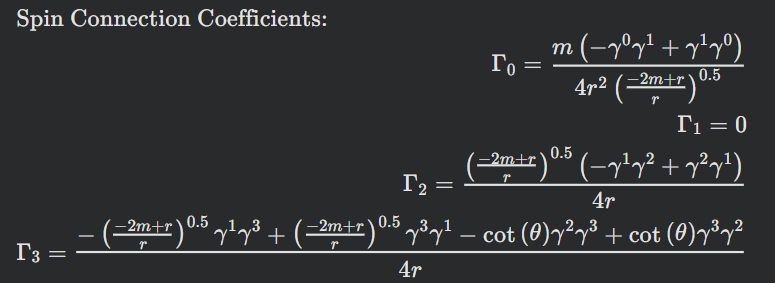

### Matrik Dirac

In [ ]:
from sympy.physics.matrices import mgamma
from sympy import Matrix

# Get the 4x4 gamma matrices for indices 0, 1, 2, 3
dirac_matrices = [mgamma(i) for i in range(4)]

# Display them using IPython display
for i, mat in enumerate(dirac_matrices):
    print(f"\nGamma^{i}:")
    display(Matrix(mat))


Gamma^0:


Matrix([
[1, 0,  0,  0],
[0, 1,  0,  0],
[0, 0, -1,  0],
[0, 0,  0, -1]])


Gamma^1:


Matrix([
[ 0,  0, 0, 1],
[ 0,  0, 1, 0],
[ 0, -1, 0, 0],
[-1,  0, 0, 0]])


Gamma^2:


Matrix([
[ 0, 0, 0, -I],
[ 0, 0, I,  0],
[ 0, I, 0,  0],
[-I, 0, 0,  0]])


Gamma^3:


Matrix([
[ 0, 0, 1,  0],
[ 0, 0, 0, -1],
[-1, 0, 0,  0],
[ 0, 1, 0,  0]])

### Aljabar Komutator Dirac $[\gamma^a, \gamma^b]$


In [ ]:
def commutator(A, B):
    return A * B - B * A

# Calculate and display the commutators
for i in range(4):
    for j in range(i + 1, 4):
        comm = commutator(dirac_matrices[i], dirac_matrices[j])
        display(Math(f"[\\gamma^{i}, \\gamma^{j}] = "))
        display(Matrix(comm))

<IPython.core.display.Math object>

Matrix([
[0, 0, 0, 2],
[0, 0, 2, 0],
[0, 2, 0, 0],
[2, 0, 0, 0]])

<IPython.core.display.Math object>

Matrix([
[  0,    0,   0, -2*I],
[  0,    0, 2*I,    0],
[  0, -2*I,   0,    0],
[2*I,    0,   0,    0]])

<IPython.core.display.Math object>

...

Matrix([
[-2*I,   0,    0,   0],
[   0, 2*I,    0,   0],
[   0,   0, -2*I,   0],
[   0,   0,    0, 2*I]])

<IPython.core.display.Math object>

Matrix([
[ 0, 2,  0, 0],
[-2, 0,  0, 0],
[ 0, 0,  0, 2],
[ 0, 0, -2, 0]])

<IPython.core.display.Math object>

Matrix([
[   0, -2*I,    0,    0],
[-2*I,    0,    0,    0],
[   0,    0,    0, -2*I],
[   0,    0, -2*I,    0]])

### Substitusi Numerik ke Koefisien Fock-Ivanenko

In [ ]:
from sympy.physics.matrices import mgamma
import re

# Memastikan matriks Dirac numerik didefinisikan
dirac_matrices = [mgamma(i) for i in range(4)]

def get_index_from_label(label):
    """Ekstrak angka pertama yang ditemukan dalam string label (misal '\\gamma^0' -> 0)"""
    match = re.search(r'\d+', str(label))
    return int(match.group()) if match else 0

def evaluate_gamma_numerical(expr, matrices):
    """
    Fungsi untuk mengevaluasi ekspresi simbolik Gamma_a menjadi matriks numerik.
    """
    if expr == 0:
        return Matrix.zeros(4, 4)

    final_matrix = Matrix.zeros(4, 4)
    flat_expr = expr.expand()
    terms = flat_expr.as_ordered_terms() if flat_expr.is_Add else [flat_expr]

    for term in terms:
        res = term.as_coeff_Mul()
        coeff = res[0]
        ops = res[1]

        if ops.is_Mul:
            factors = ops.args
            d_mats = [f for f in factors if isinstance(f, DiracMatrix)]
            other_factors = [f for f in factors if not isinstance(f, DiracMatrix)]

            term_coeff = coeff
            for f in other_factors:
                term_coeff *= f

            if len(d_mats) == 2:
                idx0 = get_index_from_label(d_mats[0].label)
                idx1 = get_index_from_label(d_mats[1].label)
                mat_prod = matrices[idx0] * matrices[idx1]
                final_matrix += term_coeff * mat_prod
            elif len(d_mats) == 1:
                idx = get_index_from_label(d_mats[0].label)
                final_matrix += term_coeff * matrices[idx]
            else:
                final_matrix += term_coeff * Matrix.eye(4)

        elif isinstance(ops, DiracMatrix):
            idx = get_index_from_label(ops.label)
            final_matrix += coeff * matrices[idx]
        else:
            final_matrix += term * Matrix.eye(4)

    return simplify(final_matrix)

# Hitung dan tampilkan matriks numerik untuk setiap Gamma_a
numerical_Gamma = []
for i, g_sym in enumerate(Gamma):
    mat_res = evaluate_gamma_numerical(g_sym, dirac_matrices)
    numerical_Gamma.append(mat_res)
    display(Math(f"\\Gamma_{i} = "))
    display(mat_res)

<IPython.core.display.Math object>

Matrix([
[                             0,                              0,                              0, -m/(2*r**2*sqrt(-(2*m - r)/r))],
[                             0,                              0, -m/(2*r**2*sqrt(-(2*m - r)/r)),                              0],
[                             0, -m/(2*r**2*sqrt(-(2*m - r)/r)),                              0,                              0],
[-m/(2*r**2*sqrt(-(2*m - r)/r)),                              0,                              0,                              0]])

<IPython.core.display.Math object>

Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])

<IPython.core.display.Math object>

Matrix([
[I*sqrt((-2*m + r)/r)/(2*r),                           0,                          0,                           0],
[                         0, -I*sqrt(-(2*m - r)/r)/(2*r),                          0,                           0],
[                         0,                           0, I*sqrt((-2*m + r)/r)/(2*r),                           0],
[                         0,                           0,                          0, -I*sqrt(-(2*m - r)/r)/(2*r)]])

<IPython.core.display.Math object>

Matrix([
[                                        0, (-sqrt((-2*m + r)/r) + I*cot(theta))/(2*r),                                         0,                                          0],
[(sqrt((-2*m + r)/r) + I*cot(theta))/(2*r),                                          0,                                         0,                                          0],
[                                        0,                                          0,                                         0, (-sqrt((-2*m + r)/r) + I*cot(theta))/(2*r)],
[                                        0,                                          0, (sqrt((-2*m + r)/r) + I*cot(theta))/(2*r),                                          0]])